In [2]:
import pandas as pd
import matplotlib
import numpy
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import matplotlib.pyplot as plt
import json
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np
from IPython.display import display

In [3]:
#print('KDDTrain+')
df = pd.read_csv('../data/NSL_KDD-master/KDDTrain+.csv')
#print(df.head())
#print('20_Percent_Training_Set')
df = pd.read_csv('../data/NSL_KDD-master/20_Percent_Training_Set.csv')
#print(df.head())
#print('Attack_Types')
df = pd.read_csv('../data/NSL_KDD-master/Attack_Types.csv')
#print(df.head())
#print('Field_Names')
df = pd.read_csv('../data/NSL_KDD-master/Field_Names.csv')
#print(df.head())
#print('KDDTest+')
df = pd.read_csv('../data/NSL_KDD-master/KDDTest+.csv')
#print(df.head())
#print('Small_Training_Set')
df = pd.read_csv('../data/NSL_KDD-master/Small_Training_Set.csv')
#print(df.head())

In [11]:
field_names_path = '../data/NSL_KDD-master/Field_Names.csv'
fields_df = pd.read_csv(field_names_path, header=None, names=['name', 'type'])

# Los nombres originales del Field_Names.csv (41 columnas) - SIN CAMBIAR el primer nombre
column_names = fields_df['name'].tolist()

# Añadir las 2 columnas extras que están en los datos pero no en el CSV
column_names.append('label')        # Columna 42 - tipo de ataque/normal
column_names.append('difficulty_level')  # Columna 43 - nivel de dificultad

print(f"Total de columnas configuradas: {len(column_names)}")

# Cargar los datasets con todos los nombres correctos
train_df = pd.read_csv('../data/NSL_KDD-master/KDDTrain+.csv', names=column_names)
test_df = pd.read_csv('../data/NSL_KDD-master/KDDTest+.csv', names=column_names)
subset_df = pd.read_csv('../data/NSL_KDD-master/20_Percent_Training_Set.csv', names=column_names)

# Cargar Attack_Types correctamente
attack_types_df = pd.read_csv('../data/NSL_KDD-master/Attack_Types.csv', 
                             header=None, 
                             names=['attack_name', 'attack_category'])

# Configurar pandas para mejor visualización sin solapamiento
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)  # Ancho más grande para evitar solapamiento
pd.set_option('display.max_colwidth', 40)  # Máximo ancho por columna
pd.set_option('display.colheader_justify', 'left')  # Alinear encabezados

# Ahora mostrar los datos
print("=== KDDTrain+ ===")
print(f"Dimensiones: {train_df.shape}")
display(train_df.head())

print("\n" + "="*100)
print("=== KDDTest+ ===")
print(f"Dimensiones: {test_df.shape}")
display(test_df.head())

print("\n" + "="*100)
print("=== 20_Percent_Training_Set ===")
print(f"Dimensiones: {subset_df.shape}")
display(subset_df.head())

print("\n" + "="*100)
print("=== Attack_Types ===")
print(f"Dimensiones: {attack_types_df.shape}")
display(attack_types_df.head())

# Verificación adicional
print("\n" + "="*100)
print("=== VERIFICACIÓN DE COLUMNAS ===")
print(f"Primera columna: '{train_df.columns[0]}'")
print(f"Últimas 5 columnas: {list(train_df.columns[-5:])}")
print(f"¿Contiene 'difficulty_level'?: {'difficulty_level' in train_df.columns}")

Total de columnas configuradas: 43
=== KDDTrain+ ===
Dimensiones: (125973, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.00,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21



=== KDDTest+ ===
Dimensiones: (22543, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,229,10,0.0,0.00,1.0,1.0,0.04,0.06,0.00,255,10,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,136,1,0.0,0.00,1.0,1.0,0.01,0.06,0.00,255,1,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.00,0.0,0.0,1.00,0.00,0.00,134,86,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,65,0.0,0.00,0.0,0.0,1.00,0.00,1.00,3,57,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,8,0.0,0.12,1.0,0.5,1.00,0.00,0.75,29,86,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,mscan,11



=== 20_Percent_Training_Set ===
Dimensiones: (25192, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.00,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21



=== Attack_Types ===
Dimensiones: (24, 2)


,attack_name,attack_category
0,back,dos
1,buffer_overflow,u2r
2,ftp_write,r2l
3,guess_passwd,r2l
4,imap,r2l



=== VERIFICACIÓN DE COLUMNAS ===
Primera columna: 'duration'
Últimas 5 columnas: ['dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level']
¿Contiene 'difficulty_level'?: True


In [5]:
# Ver información general del dataset
df.info()

# Ver estadísticas básicas
df.describe()

# Ver cuántos valores faltantes hay en cada columna
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 43 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   0         1010 non-null   int64  
 1   tcp       1010 non-null   object 
 2   ftp_data  1010 non-null   object 
 3   SF        1010 non-null   object 
 4   491       1010 non-null   int64  
 5   0.1       1010 non-null   int64  
 6   0.2       1010 non-null   int64  
 7   0.3       1010 non-null   int64  
 8   0.4       1010 non-null   int64  
 9   0.5       1010 non-null   int64  
 10  0.6       1010 non-null   int64  
 11  0.7       1010 non-null   int64  
 12  0.8       1010 non-null   int64  
 13  0.9       1010 non-null   int64  
 14  0.10      1010 non-null   int64  
 15  0.11      1010 non-null   int64  
 16  0.12      1010 non-null   int64  
 17  0.13      1010 non-null   int64  
 18  0.14      1010 non-null   int64  
 19  0.15      1010 non-null   int64  
 20  0.16      1010 non-null   int6

0           0
tcp         0
ftp_data    0
SF          0
491         0
0.1         0
0.2         0
0.3         0
0.4         0
0.5         0
0.6         0
0.7         0
0.8         0
0.9         0
0.10        0
0.11        0
0.12        0
0.13        0
0.14        0
0.15        0
0.16        0
0.18        0
2           0
2.1         0
0.19        0
0.20        0
0.21        0
0.22        0
1           0
0.23        0
0.24        0
150         0
25          0
0.17        0
0.03        0
0.17.1      0
0.25        0
0.26        0
0.27        0
0.05        0
0.28        0
normal      0
20          0
dtype: int64

In [6]:
# ====== 1️⃣ Copiamos los datasets originales para no alterar los brutos ======
train = train_df.copy()
test = test_df.copy()

# ====== 2️⃣ Limpiar nombres de columnas ======
train.columns = train.columns.str.strip().str.replace('.', '_').str.replace(' ', '_')
test.columns = test.columns.str.strip().str.replace('.', '_').str.replace(' ', '_')

print("✅ Nombres de columnas limpiados correctamente.")
print(f"Total columnas: {len(train.columns)}")

# ====== 3️⃣ Codificar variables categóricas ======
categorical_cols = ['protocol_type', 'service', 'flag']

# Codificar las 3 columnas de entrada (protocol, service, flag)
for col in categorical_cols:
    le = LabelEncoder()
    all_values = pd.concat([train[col], test[col]])
    le.fit(all_values)
    train[col] = le.transform(train[col])
    test[col] = le.transform(test[col])

print("✅ Variables categóricas codificadas correctamente.")

# --- Codificación especial para la etiqueta 'label' ---
# Ajustamos el encoder SOLO con el train
le_label = LabelEncoder()
le_label.fit(train['label'])

# Convertimos el test de forma segura
def safe_transform_label(series, encoder):
    classes = list(encoder.classes_)
    mapping = {cls: idx for idx, cls in enumerate(classes)}
    return [mapping.get(x, -1) for x in series]  # -1 si la etiqueta no está en el encoder

train['label'] = le_label.transform(train['label'])
test['label'] = safe_transform_label(test['label'], le_label)

print("✅ Codificación segura de etiquetas completa.")
print(train[categorical_cols].head())

# ====== 4️⃣ Separar variables de entrada (X) y salida (y) ======
# Quitamos 'label' y 'difficulty_level' de las variables de entrada
X_train = train.drop(['label', 'difficulty_level'], axis=1)
y_train = train['label']

X_test = test.drop(['label', 'difficulty_level'], axis=1)
y_test = test['label']

print(f"✅ X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"✅ X_test:  {X_test.shape}, y_test:  {y_test.shape}")

# ====== 5️⃣ Escalar los valores numéricos ======
scaler = StandardScaler()

# Ajustamos el escalador en el entrenamiento y lo aplicamos a ambos conjuntos
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print("✅ Escalado de valores completado.")
print(X_train_scaled.head())

# ====== 6️⃣ Guardar datasets preprocesados ======
X_train_scaled.to_csv("../data/X_train_scaled.csv", index=False)
X_test_scaled.to_csv("../data/X_test_scaled.csv", index=False)
y_train.to_csv("../data/y_train.csv", index=False)
y_test.to_csv("../data/y_test.csv", index=False)

print("✅ Archivos preprocesados guardados en ../data/")

✅ Nombres de columnas limpiados correctamente.
Total columnas: 43
✅ Variables categóricas codificadas correctamente.
✅ Codificación segura de etiquetas completa.
   protocol_type  service  flag
0  1              20       9   
1  2              44       9   
2  1              49       5   
3  1              24       9   
4  1              24       9   
✅ X_train: (125973, 41), y_train: (125973,)
✅ X_test:  (22543, 41), y_test:  (22543,)
✅ Escalado de valores completado.
   duration  protocol_type  service   flag      src_bytes  dst_bytes  land      wrong_fragment  urgent    hot       num_failed_logins  logged_in  num_compromised  root_shell  su_attempted  num_root  num_file_creations  num_shells  num_access_files  num_outbound_cmds  is_host_login  is_guest_login  count     srv_count  serror_rate  srv_serror_rate  rerror_rate  srv_rerror_rate  same_srv_rate  diff_srv_rate  srv_diff_host_rate  dst_host_count  dst_host_srv_count  dst_host_same_srv_rate  dst_host_diff_srv_rate  dst_host_sam

In [7]:
X_train = pd.read_csv("../data/X_train_scaled.csv")
X_test = pd.read_csv("../data/X_test_scaled.csv")
y_train = pd.read_csv("../data/y_train.csv").values.ravel()  # convertir a 1D
y_test = pd.read_csv("../data/y_test.csv").values.ravel()

# Crear el clasificador
rf_model = RandomForestClassifier(
    n_estimators=100,      # 100 árboles
    random_state=42,       # para reproducibilidad
    n_jobs=-1              # usar todos los núcleos
)

# Entrenar con los datos
rf_model.fit(X_train, y_train)


RandomForestClassifier(n_jobs=-1, random_state=42)

In [8]:
y_pred = rf_model.predict(X_test)


In [9]:
# Precisión global
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Reporte de clasificación (precision, recall, F1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Matriz de confusión
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.7221

Classification Report:
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00      3750
           0       0.92      0.96      0.94       359
           1       0.00      0.00      0.00        20
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00      1231
           4       0.00      0.00      0.00         1
           5       0.58      0.98      0.73       141
           6       1.00      0.14      0.25         7
           7       0.00      0.00      0.00         2
           8       0.00      0.00      0.00        18
           9       0.96      1.00      0.98      4657
          10       0.99      1.00      0.99        73
          11       0.64      0.98      0.77      9710
          12       0.50      0.50      0.50         2
          13       1.00      0.50      0.67         2
          14       0.72      0.93      0.81        41
          15       0.75      0.97      0

In [10]:
#Usar el modelo entrenado
joblib.dump(rf_model, "../data/rf_model_nsl_kdd.pkl")
print("✅ Modelo guardado como rf_model_nsl_kdd.pkl")

✅ Modelo guardado como rf_model_nsl_kdd.pkl


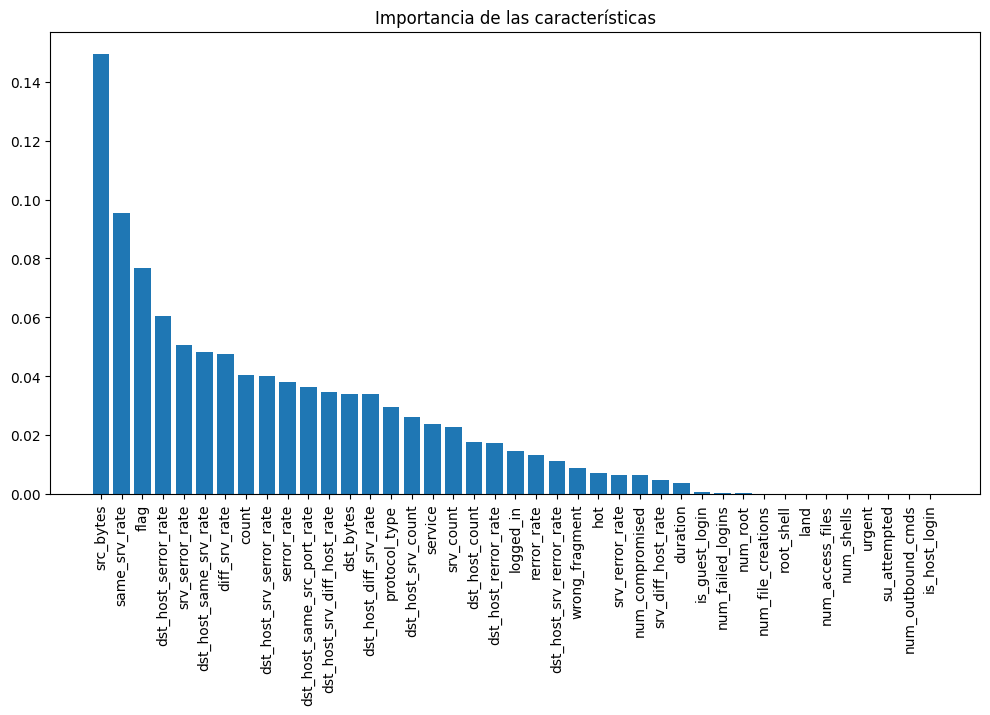

In [19]:
importances = rf_model.feature_importances_
indices = importances.argsort()[::-1]

plt.figure(figsize=(12,6))
plt.title("Importancia de las características")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=90)
plt.show()


In [22]:
# Por ejemplo, resumen de ataques por tipo
attack_counts = train_df['label'].value_counts().to_dict()

# Guardarlo como JSON
columns = list(X_train_scaled.columns)
with open("../data/columns.json", "w") as f:
    json.dump(columns, f)